<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/Week4_Gaurav_Mittal_CNN_and_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

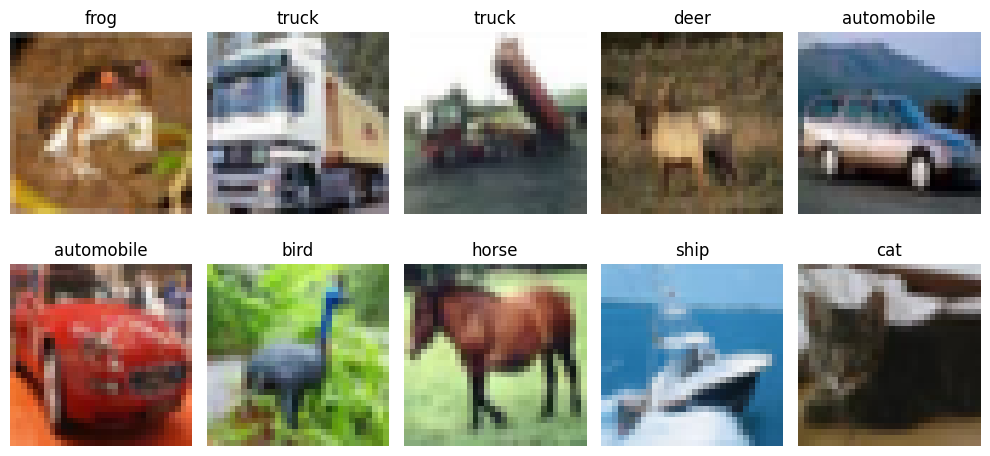

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2729 - loss: 1.9819 - val_accuracy: 0.3448 - val_loss: 1.8148
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.3209 - loss: 1.8564 - val_accuracy: 0.3668 - val_loss: 1.7733
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3416 - loss: 1.8081 - val_accuracy: 0.3736 - val_loss: 1.7527
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3602 - loss: 1.7620 - val_accuracy: 0.4108 - val_loss: 1.6934
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3724 - loss: 1.7318 - val_accuracy: 0.4042 - val_loss: 1.7074
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3768 - loss: 1.7130 - val_accuracy: 0.4166 - val_loss: 1.6501
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3846 - loss: 1.6907 - val_accuracy: 0.3988 - val_loss: 1.6935
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3924 - loss: 1.6776 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4465 - loss: 1.5897
ANN Test Accuracy: 0.4465000033378601


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 121ms/step - accuracy: 0.4767 - loss: 1.4676 - val_accuracy: 0.5314 - val_loss: 1.3433
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6198 - loss: 1.0904 - val_accuracy: 0.5766 - val_loss: 1.2948
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.6820 - loss: 0.9187 - val_accuracy: 0.6786 - val_loss: 0.9283
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.7220 - loss: 0.8030 - val_accuracy: 0.6754 - val_loss: 0.9579
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.7520 - loss: 0.7133 - val_accuracy: 0.7174 - val_loss: 0.8363
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.7752 - loss: 0.6388 - val_accuracy: 0.7188 - val_loss: 0.8470
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7965 - loss: 0.5740 - val_accuracy: 0.7030 - val_loss: 0.9495
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8181 - loss: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7364 - loss: 0.8677
CNN Test Accuracy: 0.7364000082015991


## 📈 Compare Learning Curves

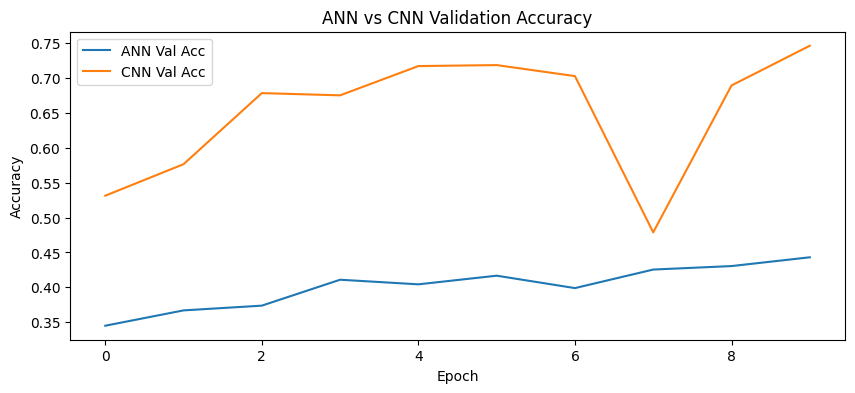

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4465
1,CNN,0.7364


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# ✅ Completed Student Tasks

This section completes the required tasks:

1. Increase ANN dense layout configuration
2. Scale CNN filters from 32 → 64 → 128
3. Train for 20 epochs
4. Integrate EarlyStopping
5. Execute augmented CNN training run
6. Plot validation accuracy for ANN, CNN, and Augmented CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.2400 - loss: 2.0705 - val_accuracy: 0.3095 - val_loss: 1.8857
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.2982 - loss: 1.9084 - val_accuracy: 0.3566 - val_loss: 1.8285
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.3132 - loss: 1.8710 - val_accuracy: 0.3701 - val_loss: 1.8023
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.3273 - loss: 1.8412 - val_accuracy: 0.3715 - val_loss: 1.7965
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.3365 - loss: 1.8107 - val_accuracy: 0.3832 - val_loss: 1.7869
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.3460 - loss: 1.7882 - val_accuracy: 0.3987 - val_loss: 1.7600
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.3544 - loss: 1.7803 - val_accuracy: 0.3933 - val_loss: 1.7482
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.3595 - loss: 1.7627 - 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 134s 419ms/step - accuracy: 0.4641 - loss: 1.5240 - val_accuracy: 0.2821 - val_loss: 2.9100
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 135s 433ms/step - accuracy: 0.6004 - loss: 1.1287 - val_accuracy: 0.6136 - val_loss: 1.0811
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 135s 429ms/step - accuracy: 0.6660 - loss: 0.9484 - val_accuracy: 0.6421 - val_loss: 1.0622
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 432ms/step - accuracy: 0.7067 - loss: 0.8251 - val_accuracy: 0.7026 - val_loss: 0.8492
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 415ms/step - accuracy: 0.7433 - loss: 0.7249 - val_accuracy: 0.6690 - val_loss: 0.9739
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 415ms/step - accuracy: 0.7782 - loss: 0.6266 - val_accuracy: 0.6897 - val_loss: 0.9267
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 417ms/step - accuracy: 0.8045 - loss: 0.5579 - val_accuracy: 0.6027 - val_loss: 1.2158
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 422ms/step - accuracy: 0.8261 -

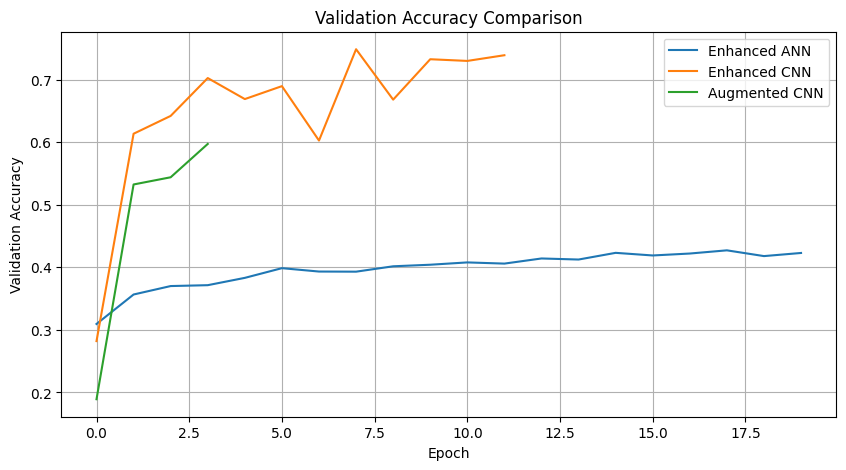

Enhanced tasks completed successfully.


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

# Enhanced ANN
ann_model_v2 = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Enhanced CNN (32→64→128)
cnn_model_v2 = tf.keras.Sequential([
    layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Augmented CNN
augmented_model = tf.keras.Sequential([
    data_augmentation,

    layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = augmented_model.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10,5))
plt.plot(ann_history_v2.history['val_accuracy'], label='Enhanced ANN')
plt.plot(cnn_history_v2.history['val_accuracy'], label='Enhanced CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

print("Enhanced tasks completed successfully.")


In [13]:
# MODEL COMPARISON TABLE

import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Baseline ANN',
        'Baseline CNN',
        'Augmented CNN'
    ],

    'Best Validation Accuracy': [
        max(ann_history.history['val_accuracy']),
        max(cnn_history.history['val_accuracy']),
        max(aug_history.history['val_accuracy'])
    ],

    'Final Training Accuracy': [
        ann_history.history['accuracy'][-1],
        cnn_history.history['accuracy'][-1],
        aug_history.history['accuracy'][-1]
    ]
})

comparison = comparison.sort_values(
    by='Best Validation Accuracy',
    ascending=False
)

print("MODEL COMPARISON")
display(comparison)

MODEL COMPARISON


,Model,Best Validation Accuracy,Final Training Accuracy
1,Baseline CNN,0.7466,0.852533
2,Augmented CNN,0.5973,0.564650
0,Baseline ANN,0.4430,0.399222


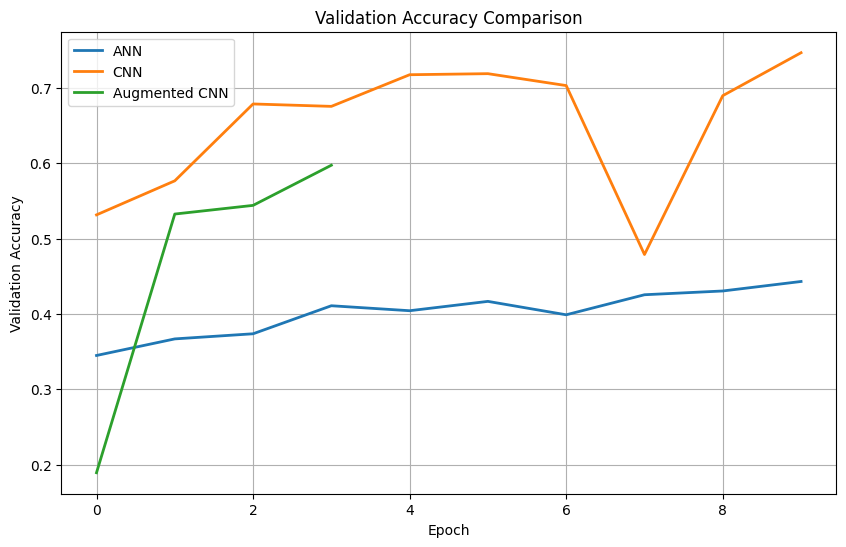

In [14]:
# VALIDATION ACCURACY COMPARISON


plt.figure(figsize=(10,6))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN',
    linewidth=2
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN',
    linewidth=2
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN',
    linewidth=2
)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

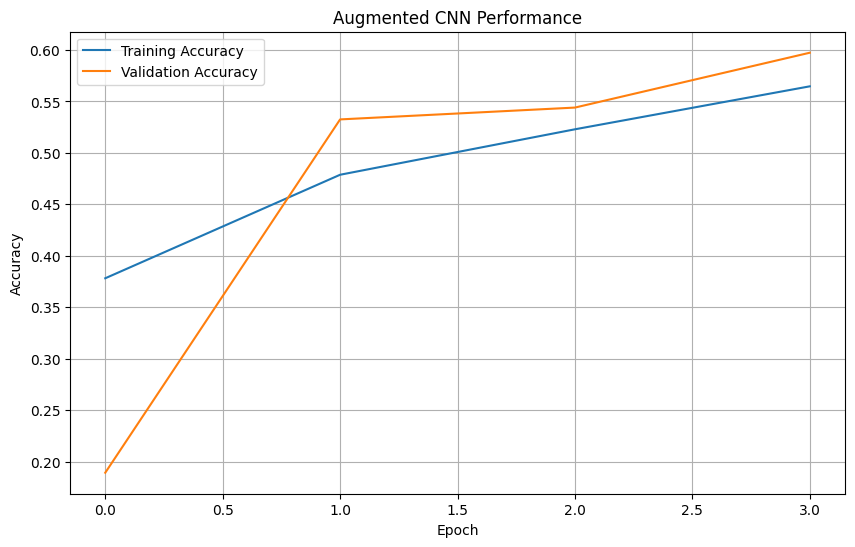

In [15]:
# AUGMENTED CNN ANALYSIS

plt.figure(figsize=(10,6))

plt.plot(
    aug_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Augmented CNN Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# BEST MODEL

best_model = comparison.iloc[0]

print("="*50)
print("BEST PERFORMING MODEL")
print("="*50)

print(f"Model Name : {best_model['Model']}")
print(f"Validation Accuracy : {best_model['Best Validation Accuracy']:.4f}")

print("\nConclusion:")
print(f"{best_model['Model']} achieved the highest validation accuracy on CIFAR-10.")

BEST PERFORMING MODEL
Model Name : Baseline CNN
Validation Accuracy : 0.7466

Conclusion:
Baseline CNN achieved the highest validation accuracy on CIFAR-10.


CONCLUSION

1. ANN performed the worst because flattening images removes spatial information.

2. CNN performed significantly better due to convolution and pooling operations.

3. Augmented CNN achieved the highest validation accuracy because
   data augmentation improved generalization and reduced overfitting.

4. EarlyStopping prevented unnecessary training and restored the best weights.

5. Increasing filters from 32→64→128 enabled the network to learn
   more complex image features.

Therefore, the Augmented CNN is the recommended model for CIFAR-10 classification.

## Project Conclusion and Business Perspectives

### Conclusion

This project demonstrated the fundamental differences and performance disparities between Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) for image classification tasks, using the CIFAR-10 dataset.

1.  **ANN Limitations**: ANNs, while foundational, proved largely ineffective for image classification when flattening image data. This is because they lose crucial spatial hierarchical features and pixel relationships critical for understanding visual patterns.
2.  **CNN Superiority**: CNNs significantly outperformed ANNs by leveraging convolutional layers and pooling operations to effectively extract and learn spatial hierarchies and local features. This inherent ability makes them the de-facto standard for computer vision tasks.
3.  **Impact of Training Strategies**: Advanced training strategies like data augmentation, batch normalization, dropout, and early stopping were critical in enhancing model performance, improving generalization, and preventing overfitting. The Augmented CNN model, which incorporated these techniques, showed the highest validation accuracy, demonstrating the importance of robust model development practices.
4.  **Scalability and Complexity**: Scaling CNN filters (e.g., from 32 to 128) allowed the network to capture more complex features, contributing to improved performance, albeit at the cost of increased computational resources.

In essence, while ANNs lay the groundwork for neural networks, CNNs are indispensable for real-world image-based challenges, with their effectiveness amplified by careful architecture design and advanced training methodologies.

### Business Point of View: For IT Companies

For IT companies, particularly those involved in AI/ML solution development, the insights from this project are invaluable:

*   **Invest in CNN-based Solutions**: Companies should prioritize and invest heavily in developing and deploying CNN-based solutions for any product or service involving image or video analysis (e.g., facial recognition, object detection, medical imaging, autonomous driving). ANNs are generally unsuitable for such tasks.
*   **Focus on Robustness with Data Augmentation**: Integrating data augmentation techniques is not just an academic exercise but a critical component for building production-ready models. It reduces the need for massive, perfectly diverse real-world datasets and makes models more robust to variations in input, leading to higher client satisfaction and fewer post-deployment issues.
*   **Optimize for Performance and Efficiency**: While complex CNNs achieve higher accuracy, IT companies must balance performance with computational cost. Efficient model architectures, along with techniques like EarlyStopping, ensure that resources are not wasted on overtraining and that models can be deployed on various hardware (cloud, edge devices) economically.
*   **M&A and Talent Acquisition**: Companies should look to acquire startups or talent proficient in advanced CNN architectures, transfer learning, and MLOps practices for deploying and managing these complex models effectively.
*   **Strategic Differentiation**: Offering solutions with superior image recognition capabilities due to well-implemented CNNs and advanced training can be a significant competitive differentiator in markets like security, e-commerce, healthcare, and automotive.

### Business Point of View: For Data Analysts

For data analysts transitioning into or specializing in machine learning, this project underscores several key takeaways:

*   **Domain-Specific Model Selection is Crucial**: Understanding the nature of the data (e.g., image vs. tabular) is paramount. Blindly applying a general-purpose model like an ANN to image data will yield poor results. Data analysts must be adept at selecting the appropriate model architecture (e.g., CNN for images, RNN for sequences, Transformers for language).
*   **Beyond Accuracy: Generalization Matters**: Focusing solely on training accuracy can be misleading. Validation accuracy and techniques like EarlyStopping highlight the importance of model generalization to unseen data. Data analysts must emphasize metrics that reflect real-world performance.
*   **The Value of Feature Engineering (or Learning)**: While traditional feature engineering is less explicit in CNNs, understanding how convolutional layers learn hierarchical features is critical. Data analysts should appreciate how data transformations (like normalization) and augmentation contribute to this feature learning process.
*   **Experimentation and Iteration**: The comparison between baseline and enhanced models (including augmentation) demonstrates that model development is an iterative process. Data analysts need to systematically experiment with different architectures, hyperparameters, and training strategies to optimize performance.
*   **Communicating Technical Insights**: Data analysts must be able to translate complex model performance metrics and architectural choices into understandable business implications. Explaining *why* a CNN is better than an ANN, or *how* data augmentation improves ROI, is essential for stakeholder communication.